## Import Dataset

In [1]:
!pip install kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!kaggle competitions download -c playground-series-s5e8
!unzip playground-series-s5e8.zip

  0% 0.00/14.7M [00:00<?, ?B/s]
100% 14.7M/14.7M [00:00<00:00, 757MB/s]
Archive:  playground-series-s5e8.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [3]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

In [4]:
train.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         750000 non-null  int64 
 1   age        750000 non-null  int64 
 2   job        750000 non-null  object
 3   marital    750000 non-null  object
 4   education  750000 non-null  object
 5   default    750000 non-null  object
 6   balance    750000 non-null  int64 
 7   housing    750000 non-null  object
 8   loan       750000 non-null  object
 9   contact    750000 non-null  object
 10  day        750000 non-null  int64 
 11  month      750000 non-null  object
 12  duration   750000 non-null  int64 
 13  campaign   750000 non-null  int64 
 14  pdays      750000 non-null  int64 
 15  previous   750000 non-null  int64 
 16  poutcome   750000 non-null  object
 17  y          750000 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 103.0+ MB


In [6]:
train.isna().sum()

,0
id,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0


In [7]:
id_col = "id"
target = [c for c in train.columns if c not in test.columns and c != id_col][0]
X = train.drop(columns=[target])
y = train[target]
X_test = test.drop(columns=[id_col])
print("target =", target)

target = y


## EDA & Visualizations

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

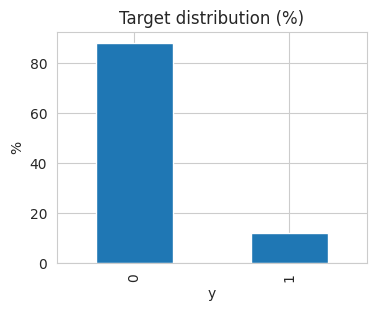

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4,3))
y.value_counts(normalize=True).mul(100).plot(kind="bar")
plt.title("Target distribution (%)")
plt.ylabel("%")
plt.show()

In [10]:
cat_cols = X.select_dtypes(include=["object","category","bool"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]
print("num cols:", len(num_cols), "cat cols:", len(cat_cols))

num cols: 8 cat cols: 9


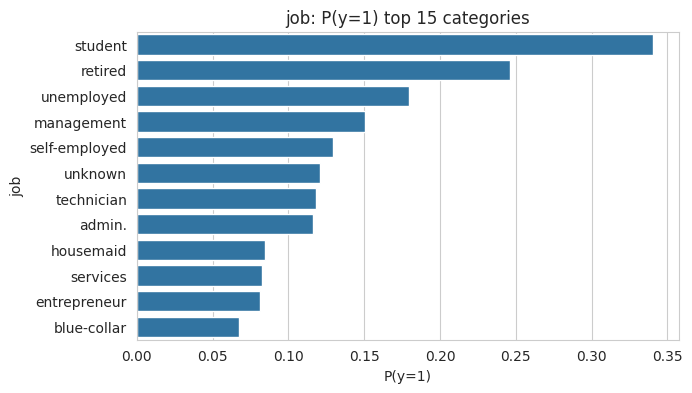

In [11]:
col = cat_cols[0]
rates = train.groupby(col)[target].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(7,4))
sns.barplot(x=rates.values, y=rates.index)
plt.title(f"{col}: P({target}=1) top 15 categories")
plt.xlabel(f"P({target}=1)")
plt.show()

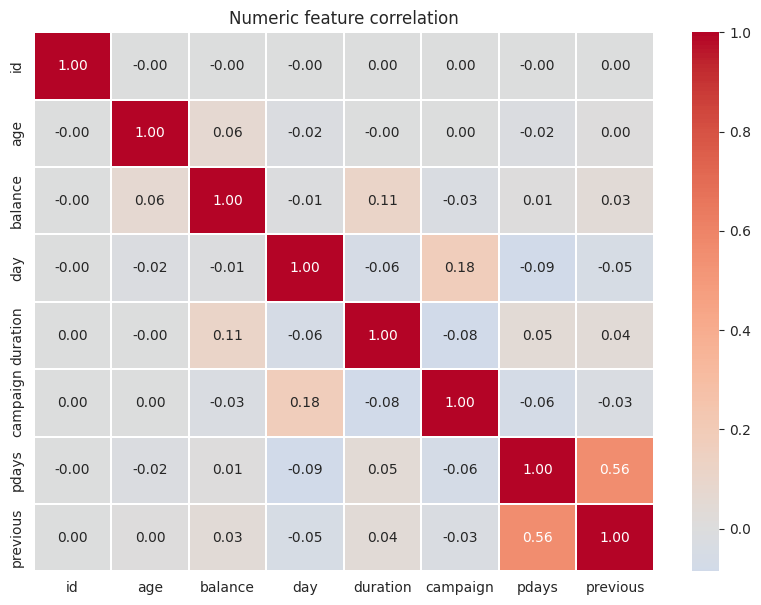

In [12]:
corr = train[num_cols].corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Numeric feature correlation")
plt.show()

## Preprocessing

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier

cat = X.select_dtypes(include=["object","category","bool"]).columns
num = [c for c in X.columns if c not in cat]

prep = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ]), cat)
])

## Pipeline

In [14]:
pipe = Pipeline([
    ("prep", prep),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42
    ))
])

## Train the Model

In [15]:
pipe.fit(X, y)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['id', 'age', 'balance',
                                                   'day', 'duration',
                                                   'campaign', 'pdays',
                                                   'previous']),
                                                 ('cat',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('enc',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(min_samples_leaf=2, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

## Predict

In [16]:
pred = pipe.predict_proba(test)[:, 1]
pred[:5]

array([0.00569441, 0.17208138, 0.01446057, 0.00124628, 0.07946849])

In [17]:
submission = sample_submission.copy()
pred_col = submission.columns[1]
submission[pred_col] = pred
submission.to_csv("submission.csv", index=False)

## Submission

In [18]:
!kaggle competitions submit -c playground-series-s5e8 -f submission.csv -m "baseline"

100% 6.42M/6.42M [00:00<00:00, 16.5MB/s]
Successfully submitted to Binary Classification with a Bank Dataset